# 1.0 Method #

In [1]:
import numpy as np
import pandas as pd
import time
from codecarbon import EmissionsTracker, OfflineEmissionsTracker
import re
from transformers import BertModel, BertTokenizer
import torch
from scipy.stats import skew
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from tabulate import tabulate
import matplotlib.pyplot as plt

[codecarbon WARNING @ 19:18:52] Nvidia GPU detected but pynvml initialization failed. Please ensure NVIDIA drivers are properly installed.


In [2]:
TEXT_COL = "sentence"
LABEL_COL = "label"

SAMPLE_SIZE = 200
RANDOM_SEED = 42
BATCH_SIZE = 64
MAX_TOKEN = 128

MODELS = [
    "google-bert/bert-base-uncased",
    "allenai/scibert_scivocab_uncased",
    "nlpaueb/legal-bert-base-uncased",
    "ahmedrachid/FinancialBERT",
    "Lianglab/PharmBERT-uncased",
    "recobo/agriculture-bert-uncased",
    "recobo/chemical-bert-uncased"
]

### 1.1 Negative Correlation Based Asymmetry Testing

In [3]:
def asymmetry_eta(x, bandwidth=None):
    """
    Estimate eta using Patil et al.-style estimator:
    eta_hat = -Corr(f_hat(X_i), F_hat(X_i))

    f_hat(X_i): leave-one-out Gaussian KDE
    F_hat(X_i): leave-one-out empirical CDF
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n < 3:
        return np.nan

    # Silverman's bandwidth
    s = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(s, iqr / 1.349) if iqr > 0 else s
    if np.isclose(sigma, 0):
        sigma = s if s > 0 else 1.0
    h = bandwidth if bandwidth is not None else 0.9 * sigma * (n ** (-1 / 5))#calculate bandwidth
    if h <= 0:
        h = 1.06 * (s if s > 0 else 1.0) * (n ** (-1 / 5))

    # Leave-one-out KDE
    diffs = (x[None, :] - x[:, None]) / h#cal culate pairwise difference
    K = stats.norm.pdf(diffs)#fit standardized distance into gaussian kernel
    np.fill_diagonal(K, 0.0)#leave one out
    f_hat = K.sum(axis=1) / ((n - 1) * h)#KED for pdf

    # Leave-one-out empirical CDF
    indicators = (x[None, :] < x[:, None]).astype(float)
    np.fill_diagonal(indicators, 0.0)
    F_hat = indicators.sum(axis=1) / (n - 1)

    if np.std(f_hat, ddof=1) == 0 or np.std(F_hat, ddof=1) == 0:
        return np.nan

    eta = -np.corrcoef(f_hat, F_hat)[0, 1]#calculate correlation

    return eta

### 1.2 Distribution distance based differentiation testing

### 1.2 All pairwise cosine similarity

In [4]:
def calculate_pairwise_cosine_distribution(embeddings):
    scores = []

    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            sim = torch.nn.functional.cosine_similarity(
                embeddings[i],
                embeddings[j],
                dim=0
            )
            scores.append(sim.item())

    return np.array(scores)

### 1.3 Pairwise Cosine simimarity (same label pairs)

### 1.4 Pairwise Cosine Similarity (Same and Different label)

## 2.0 Dataset

In [5]:
csv = "financial_original.csv"
df = pd.read_csv(csv)
print(df.head())
print(df.columns)
print(df.shape)

                                            sentence  label
0  According to Gran , the company has no plans t...      1
1  Technopolis plans to develop in stages an area...      1
2  The international electronic industry company ...      0
3  With the new production plant the company woul...      2
4  According to the company 's updated strategy f...      2
Index(['sentence', 'label'], dtype='str')
(4846, 2)


In [6]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"[?|!|\'|\"|#]", "", text)
    text = re.sub(r"[.|,|)|(|\\|/]", " ", text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def load_and_clean_dataset(csv_file):
    df = pd.read_csv(csv_file)
    df = df[[TEXT_COL, LABEL_COL]].dropna().drop_duplicates().copy()

    df["clean_sentence"] = df[TEXT_COL].apply(clean_text)
    df["length"] = df["clean_sentence"].apply(len)

    print(df.head())
    print(df[LABEL_COL].value_counts())
    print(df.shape)

    return df

In [7]:
def add_length_quantile_groups(df, num_quantiles=100):
    df = df.copy()

    quantiles = df["length"].quantile(
        [i / num_quantiles for i in range(1, num_quantiles)]
    ).tolist()

    quantiles = np.unique(quantiles).tolist()

    bins = [df["length"].min()] + quantiles + [df["length"].max()]
    labels = [f"Q{i+1}" for i in range(len(bins) - 1)]

    df["quantiles"] = pd.cut(
        df["length"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        duplicates="drop"
    )

    print(df["quantiles"].value_counts().sort_index())

    return df

In [8]:
df = load_and_clean_dataset(csv)

                                            sentence  label  \
0  According to Gran , the company has no plans t...      1   
1  Technopolis plans to develop in stages an area...      1   
2  The international electronic industry company ...      0   
3  With the new production plant the company woul...      2   
4  According to the company 's updated strategy f...      2   

                                      clean_sentence  length  
0  According to Gran the company has no plans to ...     121  
1  Technopolis plans to develop in stages an area...     186  
2  The international electronic industry company ...     224  
3  With the new production plant the company woul...     204  
4  According to the company s updated strategy fo...     198  
label
1    2873
2    1363
0     604
Name: count, dtype: int64
(4840, 4)


In [9]:
df = add_length_quantile_groups(df)
print(df.head())
print(df.columns)
print(df.shape)

quantiles
Q1      51
Q2      46
Q3      55
Q4      43
Q5      47
        ..
Q96     41
Q97     49
Q98     50
Q99     48
Q100    46
Name: count, Length: 100, dtype: int64
                                            sentence  label  \
0  According to Gran , the company has no plans t...      1   
1  Technopolis plans to develop in stages an area...      1   
2  The international electronic industry company ...      0   
3  With the new production plant the company woul...      2   
4  According to the company 's updated strategy f...      2   

                                      clean_sentence  length quantiles  
0  According to Gran the company has no plans to ...     121       Q54  
1  Technopolis plans to develop in stages an area...     186       Q86  
2  The international electronic industry company ...     224       Q95  
3  With the new production plant the company woul...     204       Q91  
4  According to the company s updated strategy fo...     198       Q89  
Index(['sente

## 3.0 Data Sampling

In [10]:
def sample_from_length_groups(df, sample_size=200, num_quantiles=100, random_seed=42):
    n_samples = sample_size // num_quantiles

    sampled_df = (
        df.groupby("quantiles", group_keys=False)
        .apply(lambda x: x.sample(n=min(n_samples, len(x)), random_state=random_seed))
        .reset_index(drop=True)
    )

    print("Actual Sample Size:", len(sampled_df))
    print("Minimum Token Count:", sampled_df["clean_sentence"].str.split().apply(len).min())
    print("Average Token Count:", sampled_df["clean_sentence"].str.split().apply(len).mean())
    print("Maximum Token Count:", sampled_df["clean_sentence"].str.split().apply(len).max())

    return sampled_df

## 3.0 Embedding

In [11]:
def compute_embeddings(texts, model_name, batch_size=64, max_token=128):
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertModel.from_pretrained(model_name)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()

    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_token
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu()

        embeddings.append(batch_embeddings)

    return torch.cat(embeddings)

## 4.0 Running Test

In [12]:
#using Eta
def run_one_model_eta(
    sampled_df,
    model_name,
    batch_size=64,
    max_token=128
):
    print(f"\nRunning model: {model_name}")

    texts = sampled_df["clean_sentence"].tolist()

    embeddings = compute_embeddings(
        texts,
        model_name,
        batch_size=batch_size,
        max_token=max_token
    )

    cosine_scores = calculate_pairwise_cosine_distribution(embeddings)

    mean_cosine = np.mean(cosine_scores)
    eta = asymmetry_eta(cosine_scores)

    print("Mean cosine:", mean_cosine)
    print("Eta:", eta)

    return {
        "model": model_name,
        "mean": mean_cosine,
        "eta": eta,
        "abs_eta": abs(eta),
        "n_pairs": len(cosine_scores),
        "cosine_scores": cosine_scores
    }

#Using Skewness
def run_one_model_skew(
    sampled_df,
    model_name,
    batch_size=64,
    max_token=128
):
    print(f"\nRunning model: {model_name}")

    texts = sampled_df["clean_sentence"].tolist()

    embeddings = compute_embeddings(
        texts,
        model_name,
        batch_size=batch_size,
        max_token=max_token
    )

    cosine_scores = calculate_pairwise_cosine_distribution(embeddings)

    mean_cosine = np.mean(cosine_scores)
    skewness = skew(cosine_scores, bias=False)

    print("Mean cosine:", mean_cosine)
    print("Skewness:", skewness)

    return {
        "model": model_name,
        "mean": mean_cosine,
        "skewness": skewness,
        "abs_skewness": abs(skewness),
        "n_pairs": len(cosine_scores),
        "cosine_scores": cosine_scores
    }

In [13]:
def running_sizes_metric(
    grouped_df,
    sample_size=200,
    num_quantiles=100,
    metric="eta",
    num_repetitions=3,
    models=MODELS,
    batch_size=64,
    max_token=128
):
    results = []

    for repetition in range(num_repetitions):
        print("=================================================")
        print(f"Repetition {repetition + 1}/{num_repetitions}")

        random_seed = np.random.randint(1000)

        sampled_df = sample_from_length_groups(
            grouped_df,
            sample_size=sample_size,
            num_quantiles=num_quantiles,
            random_seed=random_seed
        )

        for model_name in models:
            if metric == "eta":
                result = run_one_model_eta(
                    sampled_df=sampled_df,
                    model_name=model_name,
                    batch_size=batch_size,
                    max_token=max_token
                )

            elif metric == "skewness":
                result = run_one_model_skew(
                    sampled_df=sampled_df,
                    model_name=model_name,
                    batch_size=batch_size,
                    max_token=max_token
                )

            else:
                raise ValueError("metric must be 'eta' or 'skewness'")

            result["repetition"] = repetition + 1
            result["random_seed"] = random_seed
            result["sample_size"] = sample_size

            results.append(result)

    return pd.DataFrame(results)

In [14]:
#result based on eta
result_sizes_eta = running_sizes_metric(
    df,
    metric="eta",
    num_repetitions=3,
    models=MODELS,
    batch_size=64,
    max_token=128
)

Repetition 1/3
Actual Sample Size: 200
Minimum Token Count: 5
Average Token Count: 22.015
Maximum Token Count: 72

Running model: google-bert/bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Mean cosine: 0.689148378309293
Eta: 0.16716901024604153

Running model: allenai/scibert_scivocab_uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: recobo/agriculture-bert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your d

Mean cosine: 0.832858548658577
Eta: -0.1282263473485068

Running model: recobo/chemical-bert-uncased


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: recobo/chemical-bert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mean cosine: 0.8205265411629749
Eta: -0.3511084517308108


In [15]:
result_sizes_skew = running_sizes_metric(
    df,
    metric="skewness",
    num_repetitions=3,
    models=MODELS,
    batch_size=64,
    max_token=128
)

Repetition 1/3
Actual Sample Size: 200
Minimum Token Count: 5
Average Token Count: 21.695
Maximum Token Count: 45

Running model: google-bert/bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Mean cosine: 0.7047972746515394
Skewness: -0.26863690264825696

Running model: allenai/scibert_scivocab_uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: recobo/agriculture-bert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your d

Mean cosine: 0.8264892139027467
Skewness: -0.5716991265592951

Running model: recobo/chemical-bert-uncased


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: recobo/chemical-bert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mean cosine: 0.8212998570179819
Skewness: -0.7724274565803911


In [19]:
print(type(result_sizes_eta))
print(result_sizes_eta.columns)
print(result_sizes_eta.head())

<class 'pandas.DataFrame'>
Index(['model', 'mean', 'eta', 'abs_eta', 'n_pairs', 'cosine_scores',
       'repetition', 'random_seed', 'sample_size'],
      dtype='str')
                              model      mean       eta   abs_eta  n_pairs  \
0     google-bert/bert-base-uncased  0.689148  0.167169  0.167169    19900   
1  allenai/scibert_scivocab_uncased  0.759287 -0.182687  0.182687    19900   
2   nlpaueb/legal-bert-base-uncased  0.872573 -0.168196  0.168196    19900   
3         ahmedrachid/FinancialBERT  0.743025 -0.153418  0.153418    19900   
4        Lianglab/PharmBERT-uncased  0.740986 -0.164210  0.164210    19900   

                                       cosine_scores  repetition  random_seed  \
0  [0.5902587175369263, 0.7460472583770752, 0.725...           1          825   
1  [0.6084126830101013, 0.5256094336509705, 0.625...           1          825   
2  [0.8651971817016602, 0.8798391819000244, 0.858...           1          825   
3  [0.5977798104286194, 0.6213739514350

In [20]:
eta_summary_df = result_sizes_eta.groupby("model").agg(
    mean=("mean", "mean"),
    mean_std=("mean", "std"),
    eta=("eta", "mean"),
    eta_std=("eta", "std"),
    abs_eta=("abs_eta", "mean"),
    abs_eta_std=("abs_eta", "std"),
    n_pairs=("n_pairs", "mean")
).reset_index()

eta_summary_df

,model,mean,mean_std,eta,eta_std,abs_eta,abs_eta_std,n_pairs
0,Lianglab/PharmBERT-uncased,0.741978,0.007643,-0.201663,0.050581,0.201663,0.050581,19900.0
1,ahmedrachid/FinancialBERT,0.746501,0.003338,-0.138115,0.040851,0.138115,0.040851,19900.0
2,allenai/scibert_scivocab_uncased,0.764371,0.010910,-0.313839,0.113741,0.313839,0.113741,19900.0
3,google-bert/bert-base-uncased,0.690647,0.010108,0.054462,0.098022,0.061725,0.091337,19900.0
4,nlpaueb/legal-bert-base-uncased,0.873885,0.002175,-0.177507,0.078349,0.177507,0.078349,19900.0
5,recobo/agriculture-bert-uncased,0.828222,0.004163,-0.122908,0.065626,0.122908,0.065626,19900.0
6,recobo/chemical-bert-uncased,0.820117,0.001465,-0.359790,0.007580,0.359790,0.007580,19900.0


In [21]:
skew_summary_df = result_sizes_skew.groupby("model").agg(
    mean=("mean", "mean"),
    mean_std=("mean", "std"),
    skewness=("skewness", "mean"),
    skewness_std=("skewness", "std"),
    abs_skewness=("abs_skewness", "mean"),
    abs_skewness_std=("abs_skewness", "std"),
    n_pairs=("n_pairs", "mean")
).reset_index()

skew_summary_df

,model,mean,mean_std,skewness,skewness_std,abs_skewness,abs_skewness_std,n_pairs
0,Lianglab/PharmBERT-uncased,0.744632,0.008193,-0.549423,0.099889,0.549423,0.099889,19900.0
1,ahmedrachid/FinancialBERT,0.746341,0.008716,-0.803751,0.367410,0.803751,0.367410,19900.0
2,allenai/scibert_scivocab_uncased,0.760594,0.004875,-1.044476,0.823391,1.044476,0.823391,19900.0
3,google-bert/bert-base-uncased,0.691897,0.011590,-0.134859,0.195458,0.194493,0.093503,19900.0
4,nlpaueb/legal-bert-base-uncased,0.875087,0.003871,-0.993570,0.674085,0.993570,0.674085,19900.0
5,recobo/agriculture-bert-uncased,0.828921,0.004652,-1.229207,1.543117,1.229207,1.543117,19900.0
6,recobo/chemical-bert-uncased,0.821285,0.006039,-1.339185,0.544792,1.339185,0.544792,19900.0


Model Performance Ranking （In paper)

| Rank | Model | Accuracy / Micro F1 | Macro F1 | LMDFit Group |
|---:|---|---:|---:|---|
| 1 | AgricultureBERT | 0.844 | 0.830 | more-fit |
| 2 | BERT | 0.840 | 0.825 | more-fit |
| 3 | FinancialBERT | 0.841 | 0.824 | more-fit |
| 4 | SciBERT | 0.840 | 0.823 | less-fit |
| 5 | PharmBERT | 0.835 | 0.810 | more-fit |
| 6 | ChemicalBERT | 0.729 | 0.592 | less-fit |
| 7 | LegalBERT | 0.731 | 0.576 | less-fit |

## Observation: Global Cosine Similarity Distribution and Model Fitness

From the cosine similarity distribution plots, the best downstream model does not necessarily produce the most Gaussian-like or most symmetric global distribution.

BERT produces the most symmetric distribution, with Eta close to 0 and a relatively moderate mean cosine similarity. Its downstream performance is also strong, which partly supports the assumption that a more symmetric similarity distribution may indicate better model fitness.

However, AgricultureBERT achieves the best Macro F1 score, even though its cosine similarity distribution is not the most Gaussian-like. Its distribution is more concentrated and shifted to the right, with a higher mean cosine similarity. This suggests that global distributional symmetry alone is not sufficient to explain downstream classification performance.

In contrast, LegalBERT and ChemicalBERT show distributions that are highly concentrated toward high cosine similarity values. This means that many text pairs are represented as overly similar in the embedding space. Their downstream Macro F1 scores are also relatively low, which supports the paper's assumption that a cosine similarity distribution with a mean closer to 1 may indicate weaker discriminative ability.

Overall, the results suggest that Eta can be useful as an asymmetry descriptor, but it should not be used alone as a complete fitness indicator. Model fitness for text classification depends not only on the global shape of the cosine similarity distribution, but also on whether the model embeddings can separate different classes effectively.

Therefore, global Eta partially reflects model fitness, but it has limitations. A possible future improvement is to move from global cosine similarity distribution analysis to class-aware analysis, such as comparing intra-class and inter-class cosine similarity distributions.

## 5.0 Model Clustering

Mean cosine similarity measures the average closeness among all text embeddings generated by a model.

If the mean is too high, many texts are mapped very close to each other in the embedding space. This suggests that the model may not differentiate text samples well, making downstream classification harder.

Therefore, following the paper's assumption, a higher mean cosine similarity is treated as a penalty for model fitness.

<b> Higher mean value have to be punished more, but it's hard to decide the punishment, based on financial dataset, the best model architecture it actually have a relatively high mean value.</b>

<b>Clustering Logic in the LMDFit Method</b>

In the LMDFit method, each candidate pre-trained language model is first evaluated without full fine-tuning. For each model, the sampled text data are encoded into embedding vectors, and pairwise cosine similarity scores are calculated between all text embeddings. These cosine similarity values form a similarity distribution for each model.

From this distribution, two main statistical features are extracted:

- **Mean cosine similarity**
- **Skewness of the cosine similarity distribution**

The paper uses these two values as a two-dimensional representation of each model:

\[
\text{Model vector} = [\text{skewness}, \text{mean}]
\]

This means that each model becomes one point in a two-dimensional space, where one axis represents the distribution skewness and the other axis represents the mean cosine similarity.

The purpose of using these two features is based on the paper's assumption that a model with better fitness should produce embeddings that better reflect semantic differences among texts. If the mean cosine similarity is too close to 1, many text samples are mapped too closely in the embedding space, which may indicate weaker discriminative ability. At the same time, a more asymmetric or highly skewed similarity distribution may also suggest that the model does not represent the dataset structure well.

<b> What KMeans Clustering Does</b>

KMeans clustering is an unsupervised clustering method. It does not know which model is good or bad. Instead, it only groups data points based on their distance in the feature space.

In this experiment, each model is represented as:

\[
[\text{skewness}, \text{mean}]
\]

KMeans uses these two values to divide the candidate models into two clusters:

\[
n\_clusters = 2
\]

The distance between model points is usually calculated using Euclidean distance. Therefore, both skewness and mean affect how models are grouped.

For example, if two models have similar skewness and similar mean cosine similarity, KMeans is likely to put them in the same cluster. If their values are very different, they may be assigned to different clusters.

<b>How the Paper Decides More-Fit and Less-Fit Models</b>

After KMeans divides the models into two clusters, the cluster labels themselves do not have meaning yet. KMeans only produces labels such as:

- Cluster 0
- Cluster 1

It does not automatically know which cluster is more-fit.

Therefore, the paper adds an additional step. It calculates the average skewness of each cluster:

\[
\text{average skewness of Cluster 0}
\]

\[
\text{average skewness of Cluster 1}
\]

Then, the cluster whose average skewness is closer to 0 is considered the **more-fit** cluster. The other cluster is considered the **less-fit** cluster.

The logic is:

\[
|\text{average skewness}| \text{ closer to } 0
\Rightarrow
\text{more symmetric distribution}
\Rightarrow
\text{more-fit model group}
\]

Therefore, the full clustering logic is:

```text
For each model:
    compute text embeddings
    compute pairwise cosine similarities
    calculate mean and skewness

Represent each model as:
    [skewness, mean]

Apply KMeans clustering:
    divide models into two clusters

For each cluster:
    calculate average skewness

The cluster with average skewness closer to 0:
    more-fit

The other cluster:
    less-fit

In [39]:
# Cluster based on eta
def cluster_models_eta(results_df):
    results_df = results_df.copy()

    data = results_df[["eta", "mean"]].values

    labels = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    ).fit_predict(data)

    results_df["cluster"] = labels

    # Calculate average absolute eta for each cluster
    cluster_eta_score = results_df.groupby("cluster")["eta"].mean().abs()

    # Sort clusters: closest to 0 = best
    ordered_clusters = cluster_eta_score.sort_values().index.tolist()

    cluster_name_map = {
        ordered_clusters[0]: "high-fit",
        ordered_clusters[1]: "middle-fit",
        ordered_clusters[2]: "less-fit"
    }

    results_df["fit_group"] = results_df["cluster"].map(cluster_name_map)

    return results_df
    return results_df
# Cluster based on skewness
def cluster_models_skewness(results_df):
    results_df = results_df.copy()

    data = results_df[["skewness", "mean"]].values

    labels = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    ).fit_predict(data)

    results_df["cluster"] = labels

    # Calculate average absolute skewness for each cluster
    cluster_skewness_score = results_df.groupby("cluster")["skewness"].mean().abs()

    # Sort clusters: closest to 0 = best
    ordered_clusters = cluster_skewness_score.sort_values().index.tolist()

    cluster_name_map = {
        ordered_clusters[0]: "high-fit",
        ordered_clusters[1]: "middle-fit",
        ordered_clusters[2]: "less-fit"
    }

    results_df["fit_group"] = results_df["cluster"].map(cluster_name_map)

    return results_df

In [40]:
clustered_df_eta = cluster_models_eta(eta_summary_df)
clustered_df_eta

,model,mean,mean_std,eta,eta_std,abs_eta,abs_eta_std,n_pairs,cluster,fit_group
0,Lianglab/PharmBERT-uncased,0.741978,0.007643,-0.201663,0.050581,0.201663,0.050581,19900.0,1,middle-fit
1,ahmedrachid/FinancialBERT,0.746501,0.003338,-0.138115,0.040851,0.138115,0.040851,19900.0,1,middle-fit
2,allenai/scibert_scivocab_uncased,0.764371,0.010910,-0.313839,0.113741,0.313839,0.113741,19900.0,0,less-fit
3,google-bert/bert-base-uncased,0.690647,0.010108,0.054462,0.098022,0.061725,0.091337,19900.0,2,high-fit
4,nlpaueb/legal-bert-base-uncased,0.873885,0.002175,-0.177507,0.078349,0.177507,0.078349,19900.0,1,middle-fit
5,recobo/agriculture-bert-uncased,0.828222,0.004163,-0.122908,0.065626,0.122908,0.065626,19900.0,1,middle-fit
6,recobo/chemical-bert-uncased,0.820117,0.001465,-0.359790,0.007580,0.359790,0.007580,19900.0,0,less-fit


In [41]:
clustered_df_skew = cluster_models_skewness(skew_summary_df)
clustered_df_skew

,model,mean,mean_std,skewness,skewness_std,abs_skewness,abs_skewness_std,n_pairs,cluster,fit_group
0,Lianglab/PharmBERT-uncased,0.744632,0.008193,-0.549423,0.099889,0.549423,0.099889,19900.0,2,middle-fit
1,ahmedrachid/FinancialBERT,0.746341,0.008716,-0.803751,0.367410,0.803751,0.367410,19900.0,2,middle-fit
2,allenai/scibert_scivocab_uncased,0.760594,0.004875,-1.044476,0.823391,1.044476,0.823391,19900.0,0,less-fit
3,google-bert/bert-base-uncased,0.691897,0.011590,-0.134859,0.195458,0.194493,0.093503,19900.0,1,high-fit
4,nlpaueb/legal-bert-base-uncased,0.875087,0.003871,-0.993570,0.674085,0.993570,0.674085,19900.0,0,less-fit
5,recobo/agriculture-bert-uncased,0.828921,0.004652,-1.229207,1.543117,1.229207,1.543117,19900.0,0,less-fit
6,recobo/chemical-bert-uncased,0.821285,0.006039,-1.339185,0.544792,1.339185,0.544792,19900.0,0,less-fit


 Three-Cluster Additional Analysis

The original LMDFit method uses KMeans with \(k=2\) to divide models into more-fit and less-fit groups. However, in the repeated-sampling result, BERT appears to be far from the other models in the eta-mean space. Therefore, I also tested KMeans with \(k=3\) as an additional analysis.

In this version, the models are divided into three groups: high-fit, middle-fit, and less-fit. The clustering still uses the two-dimensional vector \([\eta, \text{mean}]\) or \([\text{skewness}, \text{mean}]\). After clustering, the clusters are ranked by the absolute value of their average asymmetry metric. The cluster whose average eta or skewness is closest to 0 is labeled high-fit, the next one is labeled middle-fit, and the most asymmetric cluster is labeled less-fit.

This is not a replacement for the original LMDFit binary clustering, but it helps visualize whether the candidate models form more than two natural groups.

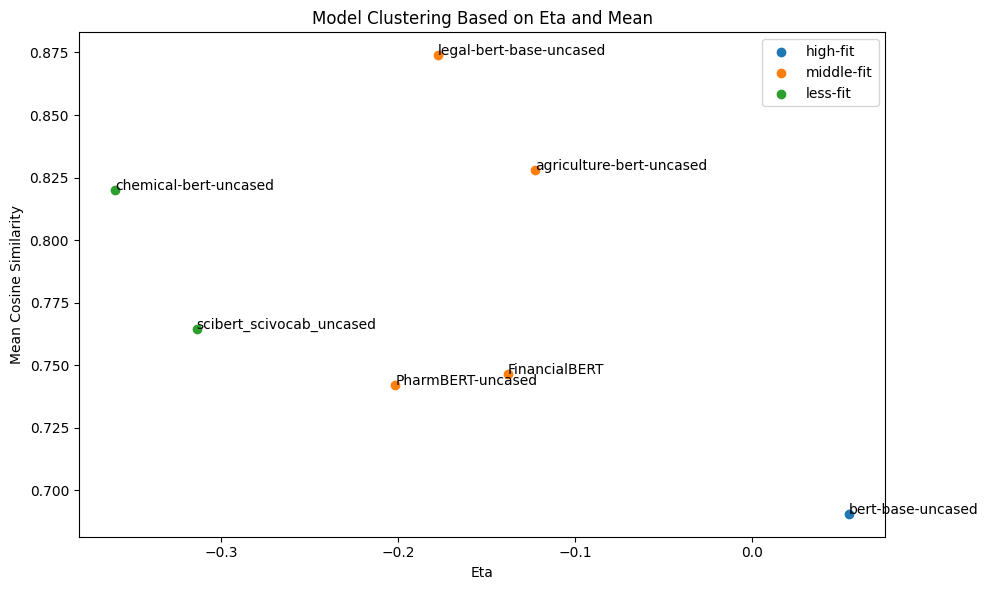

In [ ]:
plt.figure(figsize=(10, 6))

for group in ["high-fit", "middle-fit", "less-fit"]:
    sub = clustered_df_eta[clustered_df_eta["fit_group"] == group]

    if sub.empty:
        continue

    plt.scatter(
        sub["eta"],
        sub["mean"],
        label=group
    )

    for _, row in sub.iterrows():
        name = row["model"].split("/")[-1]
        plt.annotate(name, (row["eta"], row["mean"]))

plt.xlabel("Eta")
plt.ylabel("Mean Cosine Similarity")
plt.title("Model Clustering Based on Eta and Mean")
plt.legend()
plt.tight_layout()
plt.show()

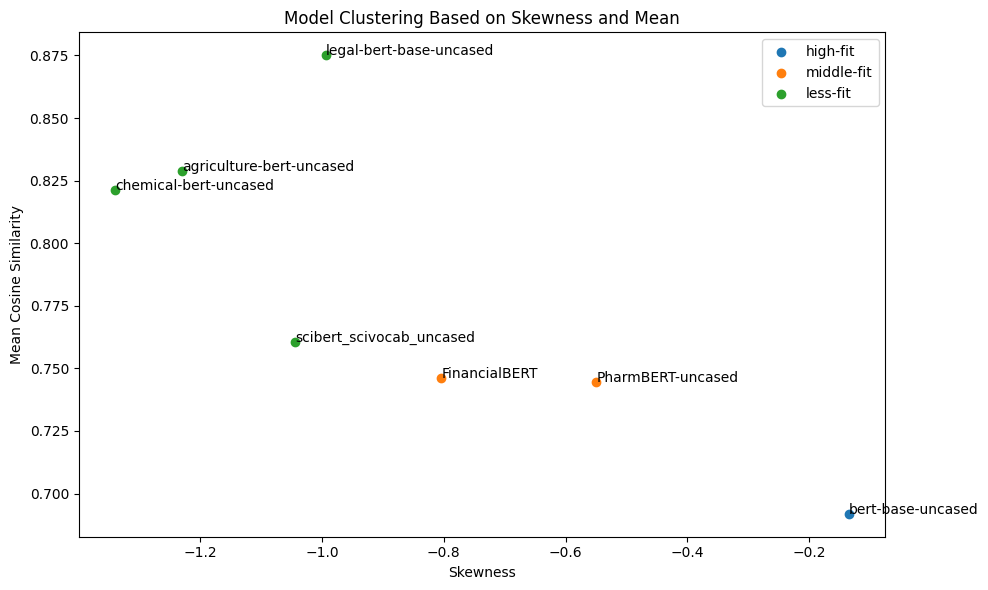

In [44]:
plt.figure(figsize=(10, 6))

for group in ["high-fit", "middle-fit", "less-fit"]:
    sub = clustered_df_skew[clustered_df_skew["fit_group"] == group]

    if sub.empty:
        continue

    plt.scatter(
        sub["skewness"],
        sub["mean"],
        label=group
    )

    for _, row in sub.iterrows():
        name = row["model"].split("/")[-1]
        plt.annotate(name, (row["skewness"], row["mean"]))

plt.xlabel("Skewness")
plt.ylabel("Mean Cosine Similarity")
plt.title("Model Clustering Based on Skewness and Mean")
plt.legend()
plt.tight_layout()
plt.show()

## Comparison Between Eta and Skewness

The averaged repetition results show that eta-based clustering is more consistent with the downstream performance of AgricultureBERT. AgricultureBERT achieved the best Macro F1 score among the evaluated models, but in the skewness-based clustering result, it was assigned to the less-fit group because its skewness value was highly negative. This suggests that conventional skewness may over-penalize models whose global cosine similarity distributions are strongly left-skewed, even when the model performs well in downstream classification.

In contrast, eta-based clustering assigned AgricultureBERT to the more-fit group. This result is more consistent with the downstream evaluation, where AgricultureBERT obtained the highest Macro F1 score. Compared with skewness, eta appears to describe the overall asymmetry structure of the cosine similarity distribution in a less tail-sensitive way. Therefore, eta may better preserve high-performing models that conventional skewness incorrectly rejects.

However, this does not mean that eta is always a complete indicator of model fitness. The result suggests that eta is a more suitable asymmetry descriptor than skewness in this experiment, but model fitness should still be interpreted together with mean cosine similarity and downstream metrics such as Macro F1.